In [1]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import emcee
import corner

In [2]:
pwd

'/Users/gopipatel/Saras_Model'

In [3]:
ls

Art.png                           RLC_model.ipynb
BH_MCMC.ipynb                     S11_for_freq.csv
BH_MCMC_RLC.ipynb                 SARAS_TA_Model_Main.ipynb
Joint Analysis.ipynb              SARAS_Tmeas_Sim.ipynb
Joint_Analysis_RLC+Open.ipynb     Untitled.ipynb
README.md                         report.log
RLC_TnE.ipynb                     saras3_S11_200mm_above_water.s1p


In [6]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/Users/gopipatel/Saras_Model/saras3_S11_200mm_above_water.s1p", skiprows=5))

d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]
c=3*10**8  # speed of light (m/s)
v=[d[i][0] for i in range(len(d)-1)] #frequency
df=pd.read_csv('/Users/gopipatel/Saras_Model/S11_for_freq.csv')
rlc = df[df.columns[1]].values.tolist()
gamma_Asky=[d[i][1] for i in range(len(v))]


In [21]:
cc=np.polyfit(v, gamma_Asky, 7)
p0, p1, p2, p3, p4, p5, p6, p7=cc
kk=[-2.1647133934050, 1.0147954161718808, -1.901747474016836, 1.7749120622094145, -7.94569881994538, 1.0125132848620795, 1.9275338662378406, 5.234963195655749]
print([round(c,2) for c in kk])
fit = np.polyval(cc,v)

[-2.16, 1.01, -1.9, 1.77, -7.95, 1.01, 1.93, 5.23]


In [11]:
Po=200          #Kelvin
vo=150*1e6      #Hz
a=2.5           #spectral index
P_sky= [Po*(k/vo)**-a for k in v] 

In [15]:
def Compute_Tmeas_Sky_exp( PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    c=3*1e8
    l=l
    N=8
    global rlc
    v= [d[i][0] for i in range(len(d)-1)]
    gamma_A=gamma_Asky
    PA= P_sky
    for i in range(len(freq)):
        #print(gamma_A[i])
        #gamma_A=p0*1e-48* freq[i] ** (N - 1) + p1*1e-39* freq[i] ** (N - 2) + p2*1e-31* freq[i] ** (N - 3) + p3*1e-23* freq[i] ** (N - 4) + p4*1e-15* freq[i] ** (N - 5) + p5*1e-08* freq[i] ** (N - 6) + p6*1e-01
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A[i])**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A[i])**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A[i])**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA[i]*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A[i])**2)*C))
    return(Tmeas)

In [42]:
def Compute_Tmeas_Sky(a, p0, p1, p2, p3, p4, p5, p6, p7, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    c=3*1e8
    l=l
    N=8
    v= [d[i][0] for i in range(len(d)-1)]
    Po=200          #Kelvin
    vo=150*1e6      #Hz
    a=a           #spectral index
    P_sky= [Po*(k/vo)**-a for k in v] 
    PA= P_sky
    for i in range(len(freq)):
        gamma_A=p0*1e-55* freq[i] ** (N - 1) + p1*1e-46* freq[i] ** (N - 2) + p2*1e-38* freq[i] ** (N - 3) + p3*1e-30* freq[i] ** (N - 4) + p4*1e-23* freq[i] ** (N - 5) + p5*1e-15* freq[i] ** (N - 6) + p6*1e-08*freq[i] ** (N - 7) + p7*1e-01
    
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA[i]*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return(Tmeas)

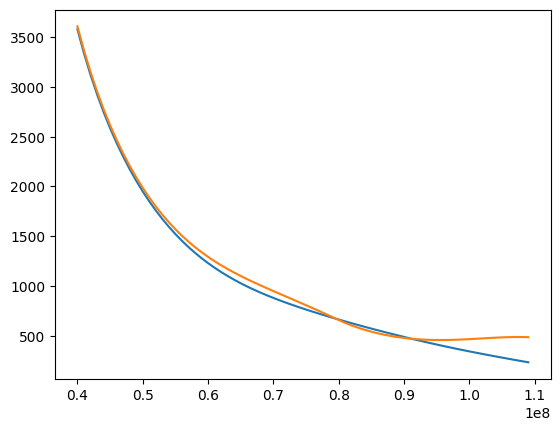

In [43]:
plt.plot(v,Compute_Tmeas_Sky_exp(70,0.3,0.1,1))
plt.plot(v,Compute_Tmeas_Sky(2.5,-2.16, 1.01, -1.9, 1.77, -7.95, 1.01, 1.93, 5.23,70,0.3,0.1,1))

In [44]:
########## Define the log-likelihood function
def log_likelihood(params,**kwargs):

    #ip_params = kwargs["ip_params"]
    PN = kwargs["PN"]
    gamma_N = kwargs["gamma_N"]
    f = kwargs["f"]
    l = kwargs["l"]
    s = kwargs["s"]
    seed=kwargs["seed"]

    # Compute TA expected
    
    #p0, p1, p2, p3, p4, p5, p6, p7 = ip_params
    
    np.random.seed(seed)
    TA_exp = Compute_Tmeas_Sky_exp( PN, gamma_N, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp=np.array(TA_exp)
    
    # Compute model TA

    a, p0, p1, p2, p3, p4, p5, p6, p7 = params
    TA_model = Compute_Tmeas_Sky(a, p0, p1, p2, p3, p4, p5, p6, p7, PN, gamma_N, f, l) 
    TA_model=np.array(TA_model)

    # Compute chi-squared
    chi2 = np.sum([((TA_exp - TA_model)/s)** 2 ]) 

    return -0.5*chi2 - np.log(math.sqrt(2*np.pi)*s)

########## Define the log-prior function
def log_prior(params,**kwargs):

    a, p0, p1, p2, p3, p4, p5, p6, p7 = params
    v=kwargs["v"]
    
    gamma_A=np.polyval([p0*1e-55, p1*1e-46, p2*1e-38, p3*1e-30, p4*1e-23, p5*1e-15, p6*1e-08, p7*1e-01],v)
    if np.all((gamma_A >= 0) & (gamma_A <= 1)):
        return 0.0  # Uniform prior
    return -np.inf #reject
    
######### Define the full log-probability function
    
def log_probability(params,**kwargs):
    lp = log_prior(params,**kwargs)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params,**kwargs)


########## MCMC for RLC Coeffs.
def evolve_MCMC_Sky(**kwargs):
        
    ## Number of walkers and steps
    
    ndim = 9  # Number of parameters
    nwalkers = 200  # Number of MCMC walkers
    nsteps = kwargs["nsteps"]  # Number of MCMC steps per walker
    
    ## Initialize walkers around a random point in parameter space
    
    initial_value = kwargs["initial_value"] 

    ## Starting positions for the walkers
    seed=kwargs["seed"]
    np.random.seed(seed+1)
    
    pos= initial_value + 1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*
    
    """
    ## for making sure only positive positional values
    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    """ 
    def wrap_log_probability(params):
        return log_probability(params, **kwargs)
    
    ## Set up the MCMC sampler
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, wrap_log_probability, threads=10)
    
    ## Run MCMC
    
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ## Extract the samples
    
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=500, flat=True)

    ## Compute log-likelihoods for all samples
    
    log_likes = np.array([log_likelihood(p,**kwargs) for p in samples])
    
    ## Find the index of the maximum likelihood
    
    max_likelihood_index = np.argmax(log_likes)
    
    ## Get the best-fit parameters
    
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples, samples, best_fit_params

In [45]:
#Evaluate MCMC
s=0.001
seed=1
v=[d[i][0] for i in range(len(d)-1)]
nsteps=3000
PN, gamma_N, f, l=[70, 0.3, 0.1, 1]
#ip_params=[ -6.33,  2.67, -4.56,  4.17, -2.186,  5.07,  4.73]
initials=[2.3, -2.0, 0.99, -1.7, 1.5, -8.0, 0.97, 2.00, 5.00]

kwargs={"nsteps":nsteps,"initial_value":initials, "PN":PN,  "gamma_N":gamma_N, "f":f, "l":l, "s":s, "v":v, "seed":seed}

full_samples_sky, samples_sky, best_fit_params_sky= evolve_MCMC_Sky(**kwargs)

Running MCMC...


  0%|                                                  | 0/3000 [00:00<?, ?it/s]/Users/gopipatel/my_env/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████████████████████████████████| 3000/3000 [00:20<00:00, 148.52it/s]


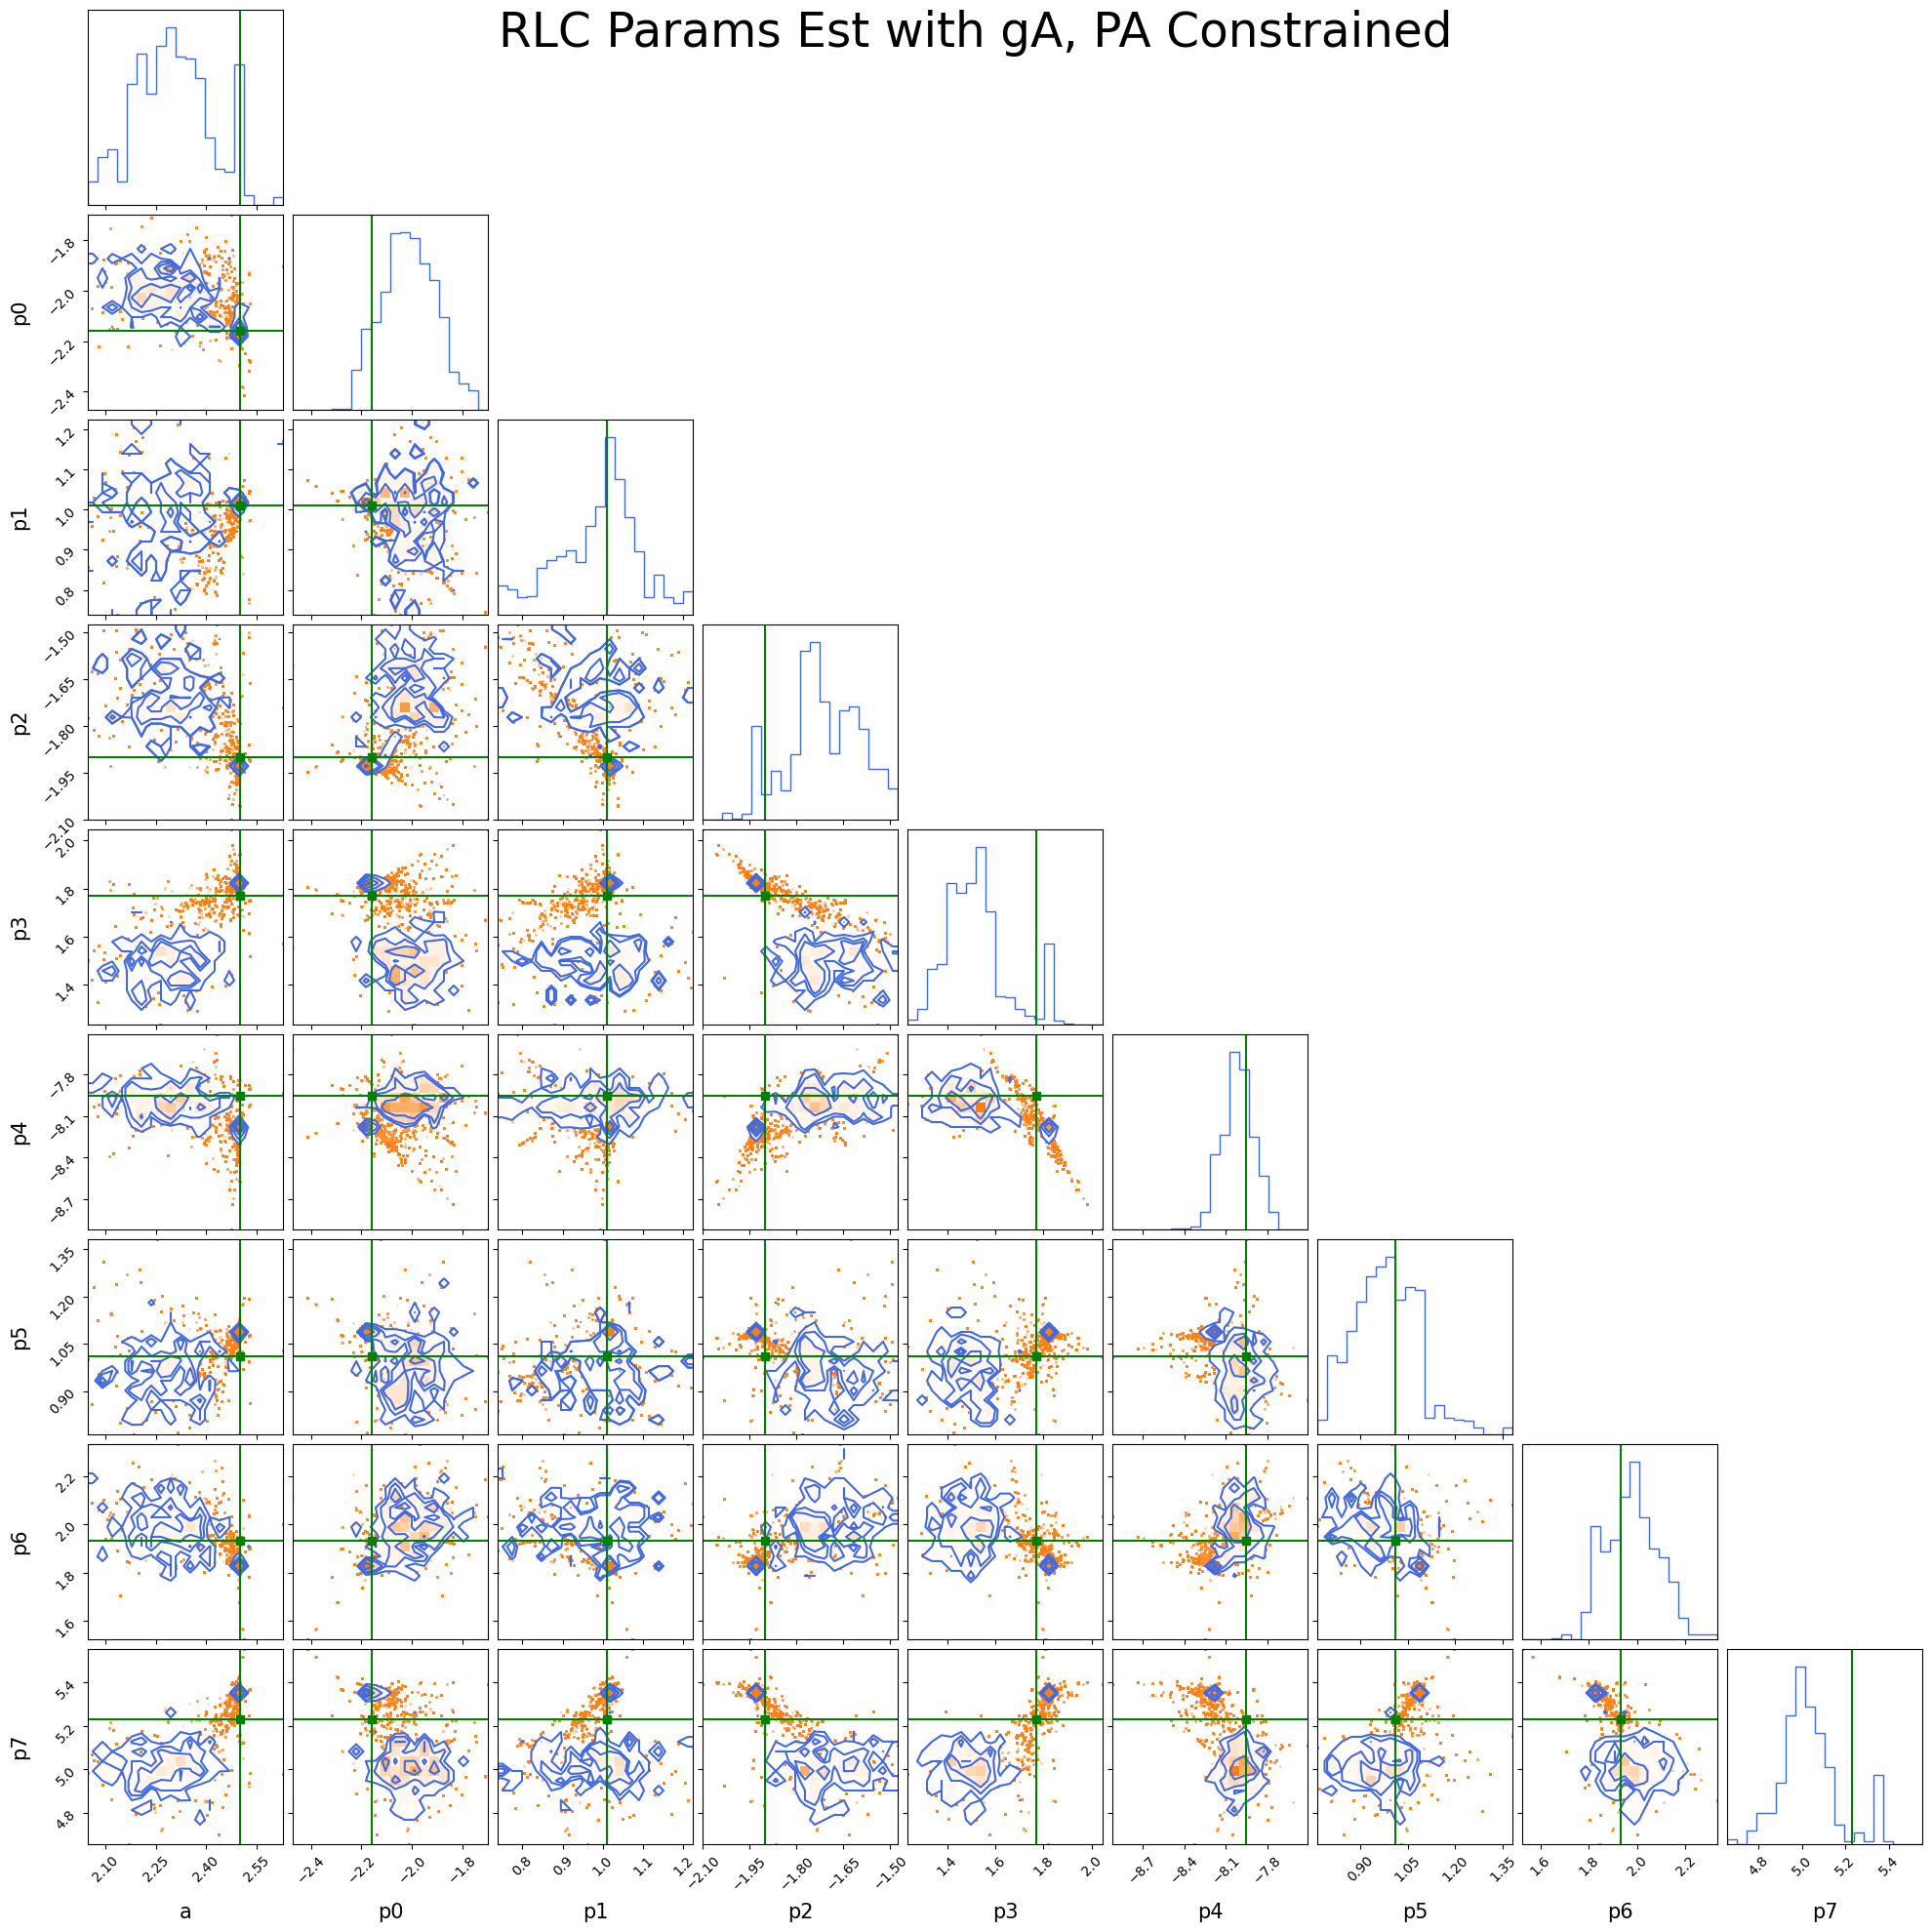

Expected: [2.5, -2.16, 1.01, -1.9, 1.77, -7.95, 1.01, 1.93, 5.23]
Best-fit parameters (Maximum Likelihood Estimate): [2.5004581949475, -2.193675519769851, 1.0321531824887933, -1.938846433061934, 1.8130048522945599, -8.15224362306968, 1.0738992399922884, 1.8190683158636092, 5.36712426123691]


In [49]:
parameter_names = ["a","p0", "p1", "p2", "p3", "p4", "p5", "p6","p7"]
#corner plot 
ip_params=[ 2.5, -2.16, 1.01, -1.9, 1.77, -7.95, 1.01, 1.93, 5.23]
fig = corner.corner(samples_sky, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
label_kwargs={"fontsize":15}, #set label size
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
plt.suptitle("RLC Params Est with gA, PA Constrained", fontsize=35)
#plt.savefig('/home/saurabhs/Documents/gopi/Saras_Model/RLC_gA_PA_2m_1.png', dpi=300)
plt.show()

#print("Expected Paramerters:",ip_params)
print("Expected:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params_sky)

[2.5004581949475, -2.193675519769851, 1.0321531824887933, -1.938846433061934, 1.8130048522945599, -8.15224362306968, 1.0738992399922884, 1.8190683158636092, 5.36712426123691]


Text(0.5, 1.0, 'S11 Obs vs Exp')

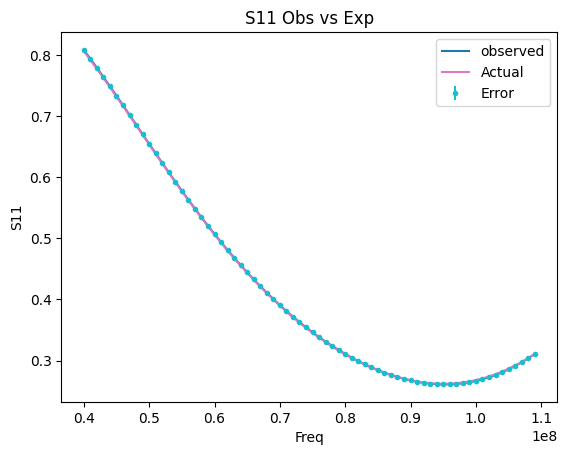

In [48]:
#Reconstruction 
print(best_fit_params_sky)
a, p0, p1, p2, p3, p4, p5, p6, p7 =best_fit_params_sky
gamma_A=np.polyval([p0*1e-55, p1*1e-46, p2*1e-38, p3*1e-30, p4*1e-23, p5*1e-15, p6*1e-08, p7*1e-01],v)
yerr=abs(gamma_Asky-gamma_A)

plt.errorbar(v, gamma_A, yerr, fmt=".C9", capsize=0, label="Error")
plt.plot(v,gamma_A,label='observed')
plt.plot(v,gamma_Asky,'tab:pink', label='Actual')
plt.legend()
plt.xlabel('Freq')
plt.ylabel('S11')
plt.title('S11 Obs vs Exp')